In [1]:
from random import gauss
import matplotlib.pyplot as plt
import numpy as np
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<h2>GARCH(2,2) Model   </h2>

$$
\alpha_{t} =\varepsilon \sqrt{ \omega +\alpha_1 \varepsilon_{t-1}^2 + \beta_1 \sigma_{t-2}^2+\alpha_1 \varepsilon_{t-1}^2 + \beta_1 \sigma_{t-2}^2}
$$

$$
\alpha_{0},\alpha_{1} \sim N(0,1)
$$

$$
\sigma_{0}=1,\sigma_2{1}=1
$$

$$
\varepsilon_{t} \sim N(0,1) 
$$

In [ ]:
n = 1000
omega = 0.5

alpha_1 = 0.1
alpha_2 = 0.2

beta_1 = 0.3
beta_2 = 0.4

test_size = int(n*0.1)

series = [gauss(0,1), gauss(0,1)]
vols = [1, 1]

for _ in range(n):
    new_vol = np.sqrt(omega + alpha_1*series[-1]**2 + alpha_2*series[-2]**2 + beta_1*vols[-1]**2 + beta_2*vols[-2]**2)
    new_val = gauss(0,1) * new_vol
    
    vols.append(new_vol)
    series.append(new_val)

Text(0.5, 1.0, 'Simulated GARCH(2,2) Data')

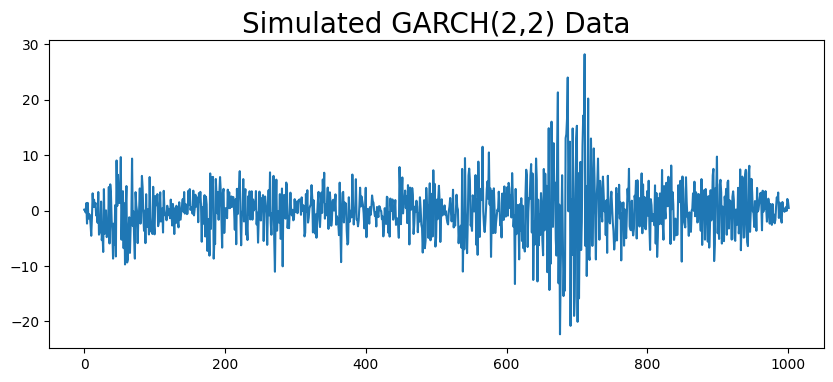

In [3]:
plt.figure(figsize=(10,4))
plt.plot(series)
plt.title('Simulated GARCH(2,2) Data', fontsize=20)

Text(0.5, 1.0, 'Data Volatility')

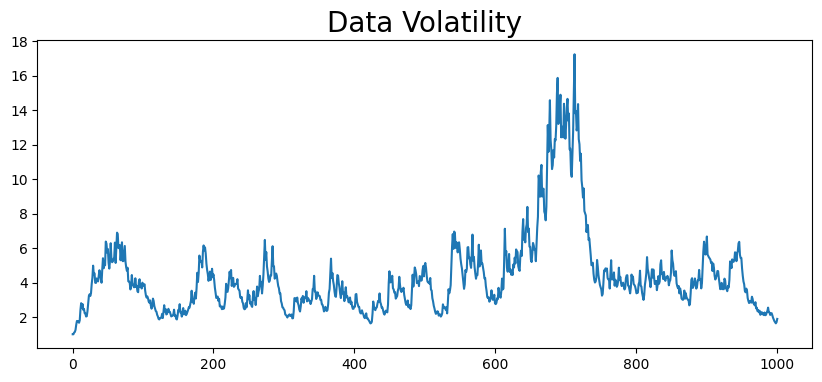

In [4]:
plt.figure(figsize=(10,4))
plt.plot(vols)
plt.title('Data Volatility', fontsize=20)

Text(0.5, 1.0, 'Data and Volatility')

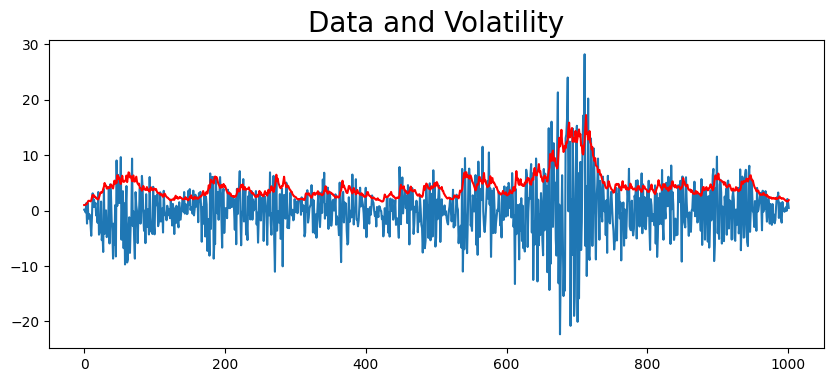

In [5]:
plt.figure(figsize=(10,4))
plt.plot(series)
plt.plot(vols, color='red')
plt.title('Data and Volatility', fontsize=20)

<h2>PACF Plot </h2>

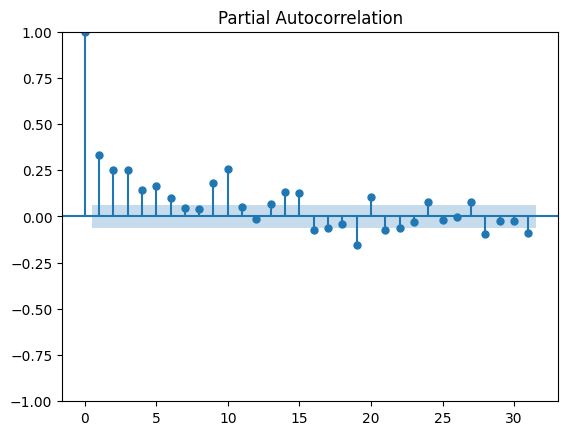

In [6]:
plot_pacf(np.array(series)**2)
plt.show()

<h2>Fit the GARCH Model</h2>

In [7]:
train, test = series[:-test_size], series[-test_size:]

In [8]:
model = arch_model(train, p=2, q=2)
model_fit = model.fit()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 3732.6863234806774
Iteration:      2,   Func. Count:     17,   Neg. LLF: 3537.746180180352
Iteration:      3,   Func. Count:     26,   Neg. LLF: 2647.6449431621622
Iteration:      4,   Func. Count:     35,   Neg. LLF: 3084.9362432699745
Iteration:      5,   Func. Count:     44,   Neg. LLF: 2533.12107253886
Iteration:      6,   Func. Count:     52,   Neg. LLF: 2516.8986874209595
Iteration:      7,   Func. Count:     60,   Neg. LLF: 2516.4280307877507
Iteration:      8,   Func. Count:     68,   Neg. LLF: 2516.0103917114748
Iteration:      9,   Func. Count:     76,   Neg. LLF: 2516.0286890880566
Iteration:     10,   Func. Count:     84,   Neg. LLF: 2515.2418700273934
Iteration:     11,   Func. Count:     91,   Neg. LLF: 2515.2358500561218
Iteration:     12,   Func. Count:     98,   Neg. LLF: 2515.2350583941316
Iteration:     13,   Func. Count:    105,   Neg. LLF: 2515.2350117200253
Iteration:     14,   Func. Count:    112,   Neg. LLF: 

In [9]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2515.24
Distribution:                  Normal   AIC:                           5042.47
Method:            Maximum Likelihood   BIC:                           5071.30
                                        No. Observations:                  902
Date:                Thu, Apr 03 2025   Df Residuals:                      901
Time:                        19:37:26   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu            -0.1157      0.108     -1.067      0.286 [ -0.328,9.685e-02]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.7436      0.247      3.006  2.649e-03   [  0.259,  1.228]
alpha[1]       0.0971  3.927e-02      2.472  1.345e-02 [2.009e-02,  0.174]
alpha[2]       0.1955  4.591e-02      4.258  2.061e-05   [  0.105,  0.285]
beta[1]        0.1077      0.174      0.620      0.535   [ -0.233,  0.448]
beta[2]        0.5749      0.148      3.895  9.820e-05   [  0.286,  0.864]
==========================================================================

Covariance estimator: robust
"""

<h2> Predict </h2>

In [10]:
predictions = model_fit.forecast(horizon=test_size)


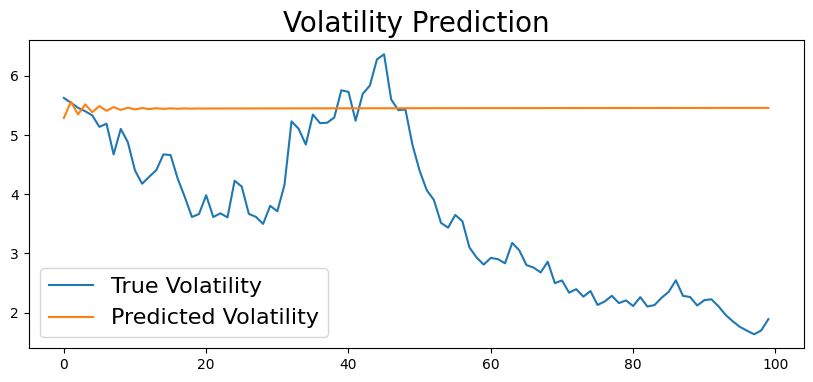

In [11]:
plt.figure(figsize=(10,4))
true, = plt.plot(vols[-test_size:])
preds, = plt.plot(np.sqrt(predictions.variance.values[-1, :]))
plt.title('Volatility Prediction', fontsize=20)
plt.legend(['True Volatility', 'Predicted Volatility'], fontsize=16)

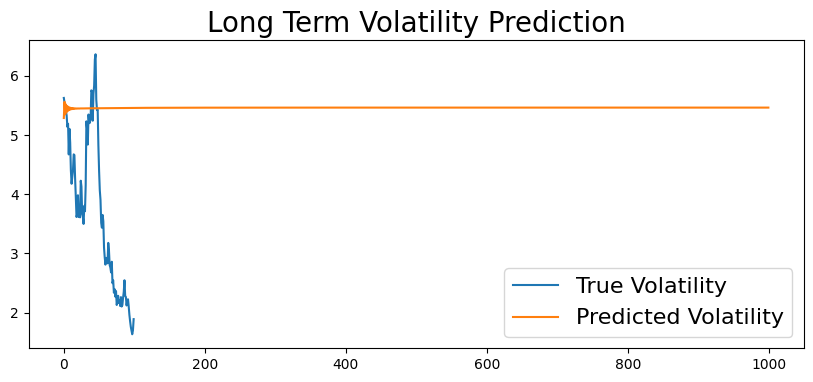

In [12]:
predictions_long_term = model_fit.forecast(horizon=1000)
plt.figure(figsize=(10,4))
true, = plt.plot(vols[-test_size:])
preds, = plt.plot(np.sqrt(predictions_long_term.variance.values[-1, :]))
plt.title('Long Term Volatility Prediction', fontsize=20)
plt.legend(['True Volatility', 'Predicted Volatility'], fontsize=16)

<h2>  Rolling Forecast Origin </h2>

In [13]:
rolling_predictions = []
for i in range(test_size):
    train = series[:-(test_size-i)]
    model = arch_model(train, p=2, q=2)
    model_fit = model.fit(disp='off')
    pred = model_fit.forecast(horizon=1)
    rolling_predictions.append(np.sqrt(pred.variance.values[-1,:][0]))

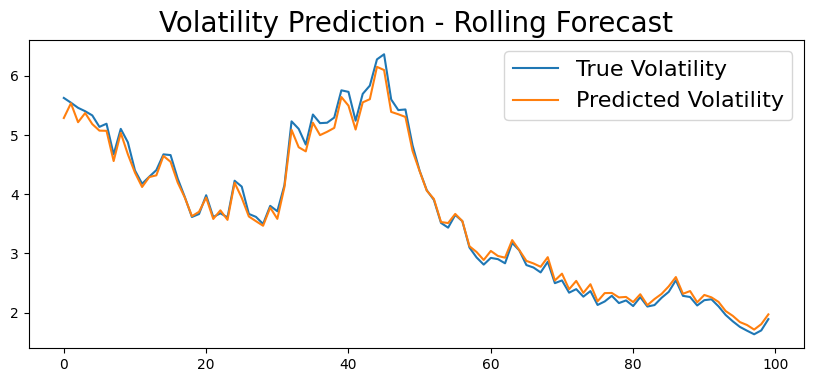

In [14]:
plt.figure(figsize=(10,4))
true, = plt.plot(vols[-test_size:])
preds, = plt.plot(rolling_predictions)
plt.title('Volatility Prediction - Rolling Forecast', fontsize=20)
plt.legend(['True Volatility', 'Predicted Volatility'], fontsize=16)